In [1]:
import  seaborn as sns
import matplotlib.pyplot as plt
tips=sns.load_dataset('tips')


In [2]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [3]:
from scipy import stats

In [4]:
stats.kurtosis(tips['tip'])

# lopto Kurtosis

np.float64(3.5495519893455114)

In [5]:
stats.skew(tips['tip'])
# Right skewness mean>median>mode

np.float64(1.4564266884221506)

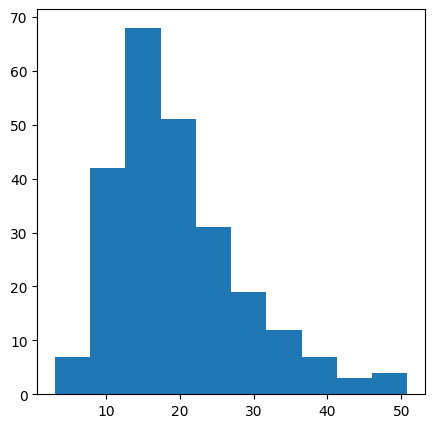

In [6]:
plt.figure(figsize=(5,5))
plt.hist(tips['total_bill'])
plt.show()


<Axes: xlabel='total_bill'>

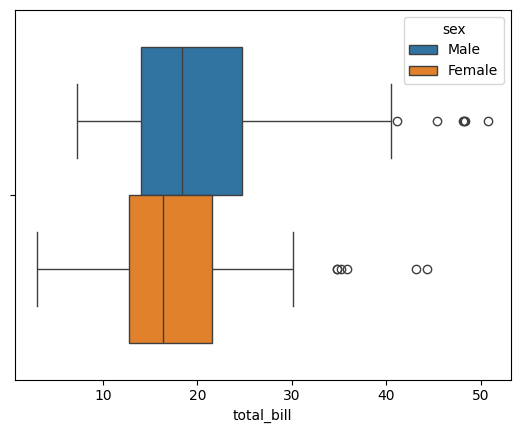

In [7]:
# Bivariate analysis
sns.boxplot(data=tips,x='total_bill',hue='sex')


In [8]:
a=tips['smoker'].value_counts()




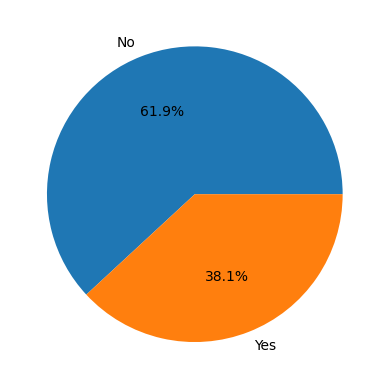

In [9]:
plt.pie(a,labels=a.index,autopct='%1.1f%%')
plt.show()

Scalling

Code  of Outlier

In [10]:
import pandas as pd

# Example data
data = {'values': [10, 12, 13, 15, 18, 19, 20, 25, 30, 100]}
df = pd.DataFrame(data)

# Calculate Q1, Q3 and IQR
Q1 = df['values'].quantile(0.25)
Q3 = df['values'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df['values'] < lower_bound) | (df['values'] > upper_bound)]
print("Outliers:")
print(outliers)

# Remove outliers
df_clean = df[(df['values'] >= lower_bound) & (df['values'] <= upper_bound)]
print("\nData without outliers:")
print(df_clean)


Outliers:
   values
9     100

Data without outliers:
   values
0      10
1      12
2      13
3      15
4      18
5      19
6      20
7      25
8      30


Standardizaton formula 

In [11]:

import seaborn as sns

df=sns.load_dataset('tips')
from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.impute import  KNNImputer,SimpleImputer

In [12]:

df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [13]:
from sklearn.preprocessing import StandardScaler

ss= StandardScaler()

a=ss.fit_transform(df[['total_bill','tip']])





In [14]:
import pandas as pd

pd.DataFrame(a,columns=['total_bill','tip'])

,total_bill,tip
0,-0.314711,-1.439947
1,-1.063235,-0.969205
2,0.137780,0.363356
3,0.438315,0.225754
4,0.540745,0.443020
...,...,...
239,1.040511,2.115963
240,0.832275,-0.722971
241,0.324630,-0.722971
242,-0.221287,-0.904026


In [15]:

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
a = ohe.fit_transform(df[['sex', 'smoker']]).toarray()




In [16]:
pd.DataFrame(a,columns=ohe.get_feature_names_out())

,sex_Female,sex_Male,smoker_No,smoker_Yes
0,1.0,0.0,1.0,0.0
1,0.0,1.0,1.0,0.0
2,0.0,1.0,1.0,0.0
3,0.0,1.0,1.0,0.0
4,1.0,0.0,1.0,0.0
...,...,...,...,...
239,0.0,1.0,1.0,0.0
240,1.0,0.0,0.0,1.0
241,0.0,1.0,0.0,1.0
242,0.0,1.0,1.0,0.0


In [17]:
import seaborn as sns

df=sns.load_dataset('tips')
from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.impute import  KNNImputer,SimpleImputer

In [18]:
# atep 3 :Define the feature group

num_feature = df.select_dtypes(exclude='category').columns
cat_feature = df.select_dtypes(include='category').columns
num_feature




Index(['total_bill', 'tip', 'size'], dtype='object')

In [19]:
# Step 4  Build preprossing

num_pipe =Pipeline(steps= [
    ("impute",KNNImputer(n_neighbors=4)),
    ("scale",StandardScaler())
])
num_pipe

,steps,"[('impute', ...), ('scale', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,n_neighbors,4
,weights,'uniform'
,metric,'nan_euclidean'
,copy,True
,add_indicator,False
,keep_empty_features,False


In [20]:

# oneHotEncoder :handle_unkunown ='ignore'  avoid error on  unseen caterories

ohe =OneHotEncoder(handle_unknown='ignore')
cat_pipe =Pipeline(steps= [
    ('impute',SimpleImputer(strategy="most_frequent")),
    ('ohe',OneHotEncoder(handle_unknown='ignore',drop='first'))
])

preproess  =ColumnTransformer(
    transformers=[
        ("num", num_pipe,num_feature),
        ("cat",cat_pipe,cat_feature)

    ]
)
ohe
cat_pipe
preproess


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,4
,weights,'uniform'


In [21]:
transform_data =preproess.fit_transform(df)

In [22]:
cat_column_freature =preproess.named_transformers_['cat'].get_feature_names_out(cat_feature)


In [23]:
cat_column_freature

array(['sex_Male', 'smoker_Yes', 'day_Sat', 'day_Sun', 'day_Thur',
       'time_Lunch'], dtype=object)

In [24]:
num_column_feature=preproess.named_transformers_['num'].get_feature_names_out()

In [25]:
num_column_feature

array(['total_bill', 'tip', 'size'], dtype=object)

In [26]:
pd.DataFrame(transform_data,columns=[list(num_column_feature)+list(cat_column_freature)])

,total_bill,tip,size,sex_Male,smoker_Yes,day_Sat,day_Sun,day_Thur,time_Lunch
0,-0.314711,-1.439947,-0.600193,0.0,0.0,0.0,1.0,0.0,0.0
1,-1.063235,-0.969205,0.453383,1.0,0.0,0.0,1.0,0.0,0.0
2,0.137780,0.363356,0.453383,1.0,0.0,0.0,1.0,0.0,0.0
3,0.438315,0.225754,-0.600193,1.0,0.0,0.0,1.0,0.0,0.0
4,0.540745,0.443020,1.506958,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
239,1.040511,2.115963,0.453383,1.0,0.0,1.0,0.0,0.0,0.0
240,0.832275,-0.722971,-0.600193,0.0,1.0,1.0,0.0,0.0,0.0
241,0.324630,-0.722971,-0.600193,1.0,1.0,1.0,0.0,0.0,0.0
242,-0.221287,-0.904026,-0.600193,1.0,0.0,1.0,0.0,0.0,0.0


In [27]:
import seaborn as sns
df=sns.load_dataset('titanic')

In [28]:
import numpy as np
df['fare'] =np.log10(df['fare'])

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [29]:
from sklearn.preprocessing import FunctionTransformer

ft=FunctionTransformer(np.square)
ft.fit_transform(df['age'])

0       484.0
1      1444.0
2       676.0
3      1225.0
4      1225.0
        ...  
886     729.0
887     361.0
888       NaN
889     676.0
890    1024.0
Name: age, Length: 891, dtype: float64

In [30]:
df['age'].apply(lambda X:np.sin(X))

0     -0.008851
1      0.296369
2      0.762558
3     -0.428183
4     -0.428183
         ...   
886    0.956376
887    0.149877
888         NaN
889    0.762558
890    0.551427
Name: age, Length: 891, dtype: float64

In [31]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,0.860338,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,1.852988,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,0.898999,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,1.725095,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,0.905796,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,1.113943,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,1.477121,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,1.370143,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,1.477121,C,First,man,True,C,Cherbourg,yes,True


In [32]:
df['fare'].apply(lambda x:1 if x>1.2 else 0)

0      0
1      1
2      0
3      1
4      0
      ..
886    0
887    1
888    1
889    1
890    0
Name: fare, Length: 891, dtype: int64

In [33]:
df['embarked'] =df['embarked'].str.lower()


In [34]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,0.860338,s,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,1.852988,c,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,0.898999,s,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,1.725095,s,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,0.905796,s,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,1.113943,s,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,1.477121,s,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,1.370143,s,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,1.477121,c,First,man,True,C,Cherbourg,yes,True


In [35]:
df['embark_town'] =df['embark_town'].str.replace('', '',regex=False)

In [36]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,0.860338,s,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,1.852988,c,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,0.898999,s,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,1.725095,s,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,0.905796,s,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,1.113943,s,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,1.477121,s,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,1.370143,s,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,1.477121,c,First,man,True,C,Cherbourg,yes,True


<Axes: xlabel='fare', ylabel='Count'>

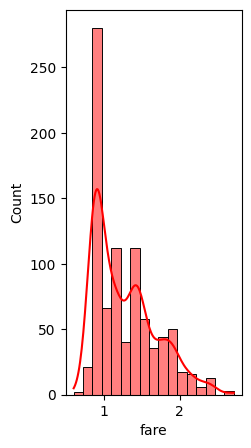

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.subplot(1,2,1)
sns.histplot(df['fare'],kde=True,color='red')

In [38]:
from sklearn.preprocessing import PowerTransformer

pt=PowerTransformer('box-cox',standardize=True)

In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
x1=np.linspace(12,34,num=15,dtype=int)
x2=np.linspace(62,86,num=15,dtype=int)
x3=np.linspace(100,134,num=15,dtype=int)

In [42]:
df=pd.DataFrame({'x1':x1,'x2':x2,'x3':x3})
df.head()

,x1,x2,x3
0,12,62,100
1,13,63,102
2,15,65,104
3,16,67,107
4,18,68,109


In [43]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]
y

0     100
1     102
2     104
3     107
4     109
5     112
6     114
7     117
8     119
9     121
10    124
11    126
12    129
13    131
14    134
Name: x3, dtype: int64

In [44]:
lr =LinearRegression()
lr.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
# Y=w1x1 + W2x2
# ya value W1 ya W2 ki ha  ids ma hum variable bhi store karshaka ha 
W1=lr.coef_[0]
W2=lr.coef_[1]
print(W1)
W2

0.16333797801517155


np.float64(1.2655209784796417)

In [46]:

b=lr.intercept_
W1,W2,b

(np.float64(0.16333797801517155),
 np.float64(1.2655209784796417),
 np.float64(19.766217680755503))

In [47]:
df['y_pred']=lr.predict(x)

In [48]:
df

,x1,x2,x3,y_pred
0,12,62,100,100.188574
1,13,63,102,101.617433
2,15,65,104,104.475151
3,16,67,107,107.169531
4,18,68,109,108.761728
5,19,70,112,111.456108
6,21,72,114,114.313826
7,23,74,117,117.171544
8,24,75,119,118.600403
9,26,77,121,121.458120


In [49]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [50]:
r2_score(y,df['y_pred'])

0.9989131773270185

In [51]:
mean_squared_error(y,df['y_pred'])

0.12010115084894317

Gradient Descent

In [52]:

def gradient_descent(x,y):
    m1=b1=0
    iteration =100
    learning_rate=0.001
    n=len(x)
    for i in range(iteration):
        y_pred =m1*x+b1
        cost_function =(1/n)*sum([val**2 for val in (y-y_pred)])
        m1_d =-(2/n)*(x*(y-y_pred))
        b1_d =-(2/n)*(y-y_pred)
        m1=m1-learning_rate*m1_d
        b1=b1-learning_rate*b1_d
    print(f"m1_new= {m1},b1_new={b1},cost_function = {cost_function}")


In [53]:
x=np.linspace(12,45,num=20,dtype=int)
y=np.linspace(22,56,num=20,dtype=int)
gradient_descent(x,y)


m1_new= [1.39811953 1.4421775  1.49057602 1.49932566 1.54714943 1.47127857
 1.44148379 1.41050093 1.43546012 1.40476199 1.34302707 1.32115234
 1.34241203 1.32237944 1.30454775 1.26228353 1.28120885 1.26753863
 1.25513513 1.24383021],b1_new=[0.11650996 0.11093673 0.09937173 0.08819563 0.08595275 0.07356393
 0.06552199 0.05877087 0.0574184  0.05202822 0.04631128 0.04261782
 0.04195038 0.03889351 0.03623744 0.03321799 0.03285151 0.03091558
 0.02918919 0.02764067],cost_function = 2.752666175196193


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [55]:
df=pd.read_csv('used-bikes.csv')
df

,bike_name,price,city,kms_driven,owner,age,power,brand,Original Price
0,TVS Star City Plus Dual Tone 110cc,35000,Ahmedabad,17654,First Owner,3,110,TVS,82500
1,Royal Enfield Classic 350cc,119900,Delhi,11000,First Owner,4,350,Royal Enfield,230000
2,Triumph Daytona 675R,600000,Delhi,110,First Owner,8,675,Triumph,1100000
3,TVS Apache RTR 180cc,65000,Bangalore,16329,First Owner,4,180,TVS,140000
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000,Bangalore,10000,First Owner,3,150,Yamaha,150000
...,...,...,...,...,...,...,...,...,...
7307,Hero Hunk Rear Disc 150cc,25000,Delhi,48587,First Owner,8,150,Hero,120000
7308,Bajaj Avenger 220cc,35000,Bangalore,60000,First Owner,9,220,Bajaj,160000
7309,Harley-Davidson Street 750 ABS,450000,Jodhpur,3430,First Owner,4,750,Harley-Davidson,630000
7310,Bajaj Dominar 400 ABS,139000,Hyderabad,21300,First Owner,4,400,Bajaj,245000


In [56]:
df.describe()

,kms_driven,age,power,Original Price
count,7312.000000,7312.000000,7312.000000,7.312000e+03
mean,23949.871718,6.733862,228.496991,1.823393e+05
std,27340.904392,3.857574,158.035118,1.835454e+05
min,1.000000,1.000000,100.000000,5.000000e+04
25%,10148.500000,4.000000,125.000000,9.000000e+04
50%,19000.000000,6.000000,160.000000,1.500000e+05
75%,30396.750000,8.000000,350.000000,2.150000e+05
max,750000.000000,63.000000,1800.000000,2.750000e+06


In [57]:
df.shape

(7312, 9)

In [58]:
df.isnull().sum()

bike_name         0
price             0
city              0
kms_driven        0
owner             0
age               0
power             0
brand             0
Original Price    0
dtype: int64

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7312 entries, 0 to 7311
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   bike_name       7312 non-null   object
 1   price           7312 non-null   object
 2   city            7312 non-null   object
 3   kms_driven      7312 non-null   int64 
 4   owner           7312 non-null   object
 5   age             7312 non-null   int64 
 6   power           7312 non-null   int64 
 7   brand           7312 non-null   object
 8   Original Price  7312 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 514.3+ KB


In [60]:
df.value_counts()

bike_name                price    city       kms_driven  owner         age  power  brand   Original Price
Yamaha YZF-R15 V3 150cc  135000   Delhi      14050       First Owner   3    150    Yamaha  205000            1
                         132000   Mumbai     579         First Owner   2    150    Yamaha  205000            1
                         131000   Hyderabad  14379       First Owner   3    150    Yamaha  205000            1
                         130000   Jhansi     3300        Second Owner  3    150    Yamaha  205000            1
                         129600   Pune       4266        First Owner   3    150    Yamaha  205000            1
                                                                                                            ..
BMW G 310 R              260000   Bangalore  11000       First Owner   3    310    BMW     325000            1
                         255000   Mohali     2200        First Owner   3    310    BMW     325000            1
BMW G 

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df['price'].dtype

dtype('O')

In [63]:
df.describe()

,kms_driven,age,power,Original Price
count,7312.000000,7312.000000,7312.000000,7.312000e+03
mean,23949.871718,6.733862,228.496991,1.823393e+05
std,27340.904392,3.857574,158.035118,1.835454e+05
min,1.000000,1.000000,100.000000,5.000000e+04
25%,10148.500000,4.000000,125.000000,9.000000e+04
50%,19000.000000,6.000000,160.000000,1.500000e+05
75%,30396.750000,8.000000,350.000000,2.150000e+05
max,750000.000000,63.000000,1800.000000,2.750000e+06


In [64]:
df

,bike_name,price,city,kms_driven,owner,age,power,brand,Original Price
0,TVS Star City Plus Dual Tone 110cc,35000,Ahmedabad,17654,First Owner,3,110,TVS,82500
1,Royal Enfield Classic 350cc,119900,Delhi,11000,First Owner,4,350,Royal Enfield,230000
2,Triumph Daytona 675R,600000,Delhi,110,First Owner,8,675,Triumph,1100000
3,TVS Apache RTR 180cc,65000,Bangalore,16329,First Owner,4,180,TVS,140000
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000,Bangalore,10000,First Owner,3,150,Yamaha,150000
...,...,...,...,...,...,...,...,...,...
7307,Hero Hunk Rear Disc 150cc,25000,Delhi,48587,First Owner,8,150,Hero,120000
7308,Bajaj Avenger 220cc,35000,Bangalore,60000,First Owner,9,220,Bajaj,160000
7309,Harley-Davidson Street 750 ABS,450000,Jodhpur,3430,First Owner,4,750,Harley-Davidson,630000
7310,Bajaj Dominar 400 ABS,139000,Hyderabad,21300,First Owner,4,400,Bajaj,245000


In [65]:
df[df['power']>1000]['power'].unique()

array([1100, 1300, 1198, 1800, 1130, 1200, 1050, 1262, 1700, 1090])

In [66]:
df.drop(['city','bike_name'],axis=1,inplace=True)
df

,price,kms_driven,owner,age,power,brand,Original Price
0,35000,17654,First Owner,3,110,TVS,82500
1,119900,11000,First Owner,4,350,Royal Enfield,230000
2,600000,110,First Owner,8,675,Triumph,1100000
3,65000,16329,First Owner,4,180,TVS,140000
4,80000,10000,First Owner,3,150,Yamaha,150000
...,...,...,...,...,...,...,...
7307,25000,48587,First Owner,8,150,Hero,120000
7308,35000,60000,First Owner,9,220,Bajaj,160000
7309,450000,3430,First Owner,4,750,Harley-Davidson,630000
7310,139000,21300,First Owner,4,400,Bajaj,245000


In [ ]:
# Create or transform feature 
# Example : If you have ha "Year column for bike "

df['Bike_Age'] =2025 - df['age']

# Drop irrelevent feature 

drop_cols = ['ID','ModelName','age']
df= df.drop(columns=drop_cols,errors='ignore')

# Define X and Y

x= df[['kms_driven','owner','power','brand','original price','Bike_Age']]

y= df['price']


# Train -test split

x_train,x_train,y_train,y_train = train_test_split(x,y,test_size=0.2,random_state =42,shuffle=True)

KeyError: 'age'